# 11장. 비젼 Transformer

In [9]:
from IPython.display import Image

## 1.  CNN, Fully Connected, Attention (Transformer)

- CNN 방식은 공간적으로 가까운 화소들간의 패턴을 찾는 방식 (지격 특성)
    - 일반적으로 지역적으로 가까운 화소가 중요하지만, 공간상 멀리 있는 화소의 정보가 현재 화소를 이해하는데 중요할 수 있음.
    - (또한 CNN의 이러한 지역특성으로 paramter 효율적이고 학습이 쉽게 이루어짐)  
    - 그림
        - 개가 어떤 동작을 하는지 보려면 (원반을 잡기위하여 공중으로 점프), 단순히 개의 주뉘 화소 정보만 가지고 되지 않고 하늘과 원반의 유무 정보가 필요.  
        
- Fully Connected
  - 그렇다고 모든 화소를 다 활용하는 원래구조인 Fully Connected 방식은 CNN의 장점을 퇴색시틴다.
  
- Attention (Transformer)
    - (책에서는 주목에 애하여 Saliency에 관련된 영상 연구도 언급하지만, 개인적으로 궂이 이와 연관을 하고 싶지 않음.) 
    - 직관적으로 말해서 **transfomer**(변환)는 입력 단계에서 명확하지 않았던 정보의 의미를 주위의 데이터를 사용한 **문맥** (context)를 통하여 정확하게 만드는 과정
        - 예를 들어, 털의 패턴이 있을때 주위에 사람 머리가 있으면 모자일 가능성이 많고, 호랑이 눈이 보이면 호랑이 표피일 가능성 높음.
        - 이러한 문맥적 **관련성**인 높은 데이터 (화소)를 찾아 내는 방법이 attension 이라는 기능
    - self attension, cross attension
        - Self Attention이란 이란 동일 입력(그림, 문장)내에서 화소영역들간의 상관적 중요도
            - 그림 (b)에서 파란색 동그란 프라스틱으로 보이는 물체는 하늘 보다는 개에 좀 더 영향을 받아 이것이 개들이 가지고 노는 원판 (프리스비임)으로 추론.  
        - cross-attension은 두개의 다름 입력 (보통은 다른 형태의 데이터, 예를 들어 이미지와 Text 간)의 상관적 중요도   
            - 다이빙 사잔에대하여 질문에 따라 주목해서 봐야 할 곳이 달라짐  
    - 식으로 표현 하면  $$ y(i) = \frac{1}{C(x)} \sum_{j}  A(x_i, x_j) g (x_j) $$
        - $x_i$, $x_j$는 단어의 임베딩 벡터/일정영역의 CNN특징백테
        - $A(x_i, X_j)$ 는 보통 cosine sim가 사용되는 유사도/상관도로 계산
        - $ g(\cdot)$는 의미변환함수 

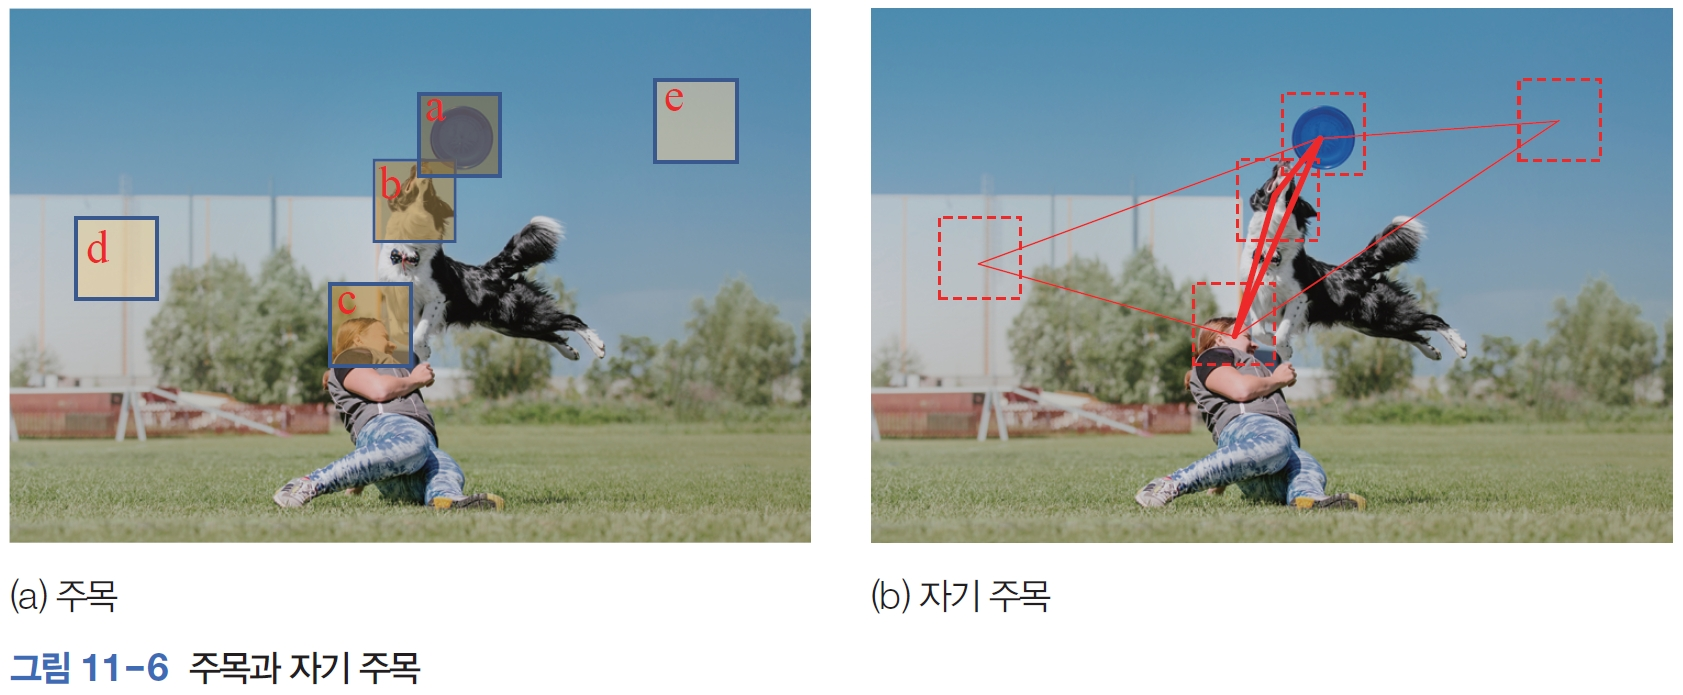

In [5]:
# Self-attention의 예 
Image("그림 11-6.jpg", width=720)

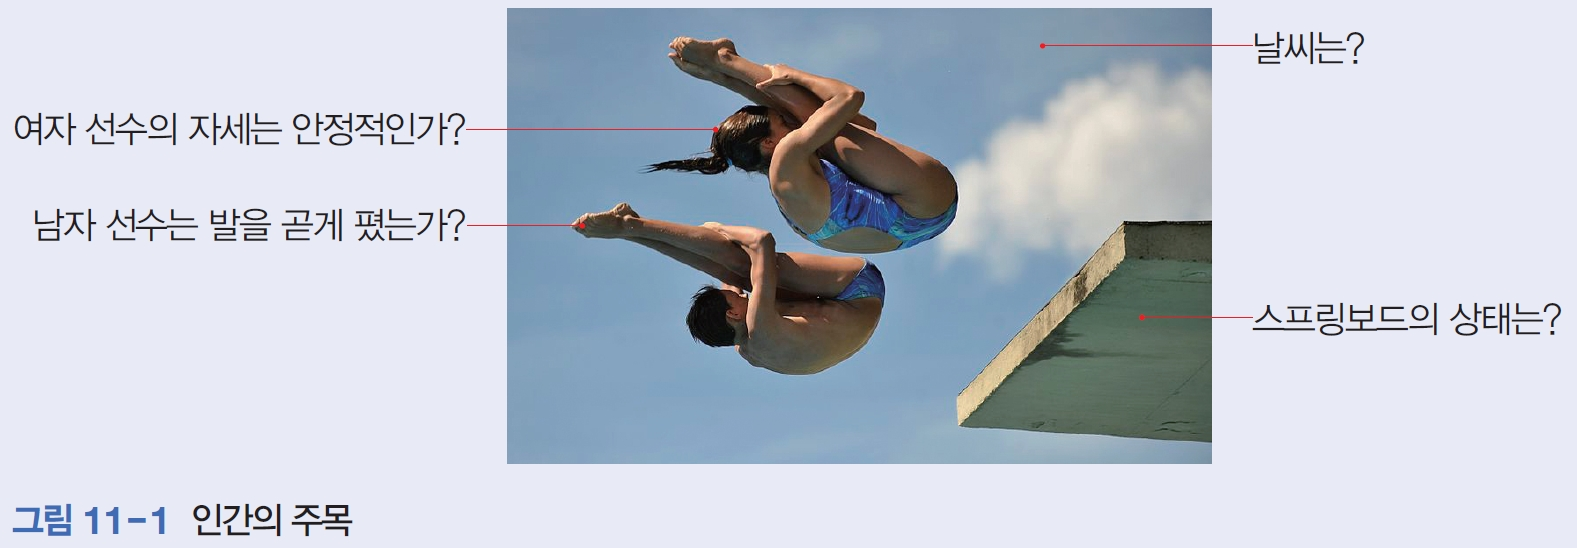

In [7]:
# Cross-attention의 예 
Image("그림 11-1.jpg", width=720)

## 2. RNN 소개 
 **note**  순환신경망에서의 주목도 의미있는 내용이나 보다 중요한 내용에 집중하기 위하여 이 강의에서는 생략하니 관심있는 학생을 읽어 보기 바란다.

## 3. 언어 모델 트랜스포머 (Language Transformer)

### 1) 트랜스포머 모델의 구조 

- 트랜스포머구조가 처음 적용된 것은  언어 모델 (번역)
    - Google이 2017년 "Attention is all you need" 라는 제목의 논문 발표 (Attension 자체는 이전에 연구가 되어 있었음)
- ViT (비젼 트랜스포머)에 어떻게 응용되었는지 이해
- 본 수업에서는 개념적으로 만 설명
   - 좀더 상세한 설명은 해당 논문과 다음 자료를 참고
        - The Illustrated Transformer, https://jalammar.github.io/illustrated-transformer/
        - Youtube의 3blue1Brown https://youtu.be/wjZofJX0v4M?si=BeLprQJLJP1UiCTt
- 동일/유사한 형태의 입-출력 관계가 여러 계층으로도 구성된 계층구조 (기존의 네트워크와 유사).  
- 처음 제안된 트랜스포머 모델은 Encoder 블럭과 Decoder 블럭의 두 단계로 구성
    - 번역작업: 인코더는 입력언어의 문장을 해석하는 용도, 디코더는 목적 언어로 문장을 생성하는 용도.
    - 최근은 LLM(GPT)은 주로 Decoder 만 사용

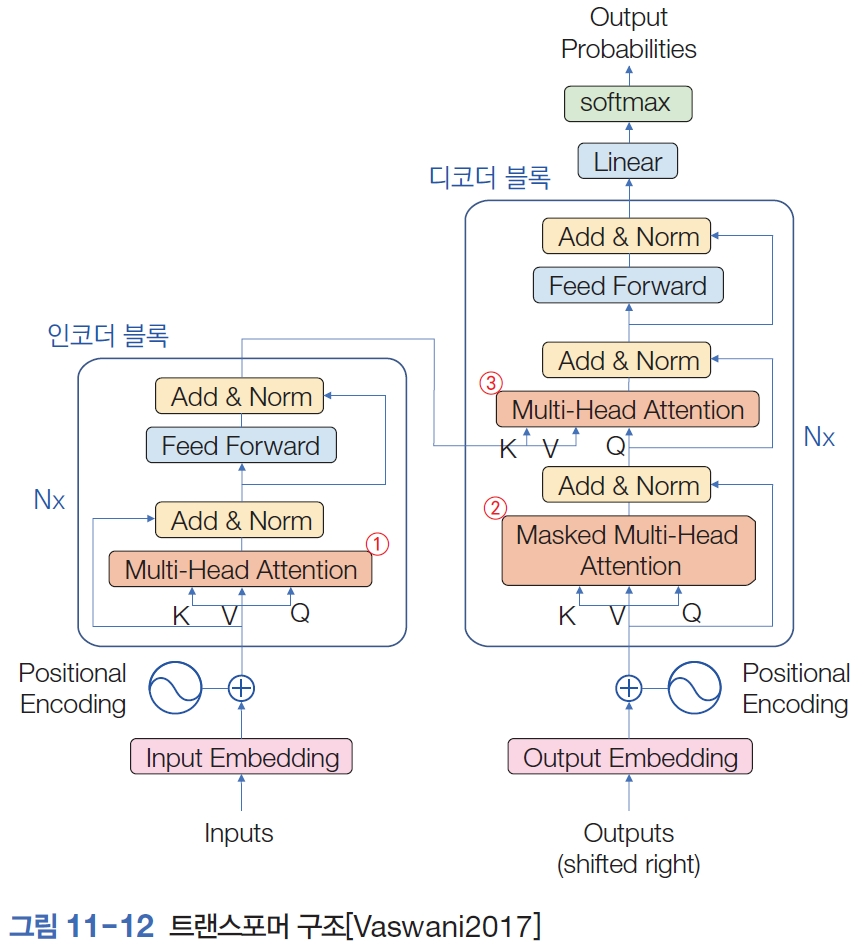

In [7]:
Image("그림 11-12.jpg", width=480)

### 2) 트랜스포머 동작 절차 

1. 입력과 출력의 단위는 토큰(단어)들 인데, vector embedding (별도의 학습된 네트워크)으로 동일한 길의의 벡터로 변환.

   - 인코더는 입력이 동시에 입력 (바교: RNN은 순차적으로 입력), 병렬 처리가 가능해 고속화 가능.   
   - 디코더의 출력은 다시 디코더의 입력으로 들어가는데, 아직 출력되지 않은 출력은 mask를 통하여 무시.   

2. 레이어 별로 순차적으로 처리
   - 아래 단계의 계층의 벡터가 다음 단계의 계층으로 이동할 때, attention 과정과 feed-forward의 두 단계를 거침.
   - 인코더에서 사용된 어텐션은 입력 자신의 문장안에서 사용되어 self-attnsion 이라고 부름
   - 디코더에서는 디코더 자체 입력간의 self-attention이후에 입력문에서와 cross-attention
   - 의미적으로 1) attention은 문맥을 사용하여 단어의 의미를 파학하는 것, 2) feed-forward 네트워크는 연상 작용, 즉 관련된 단어를 끌어내는데 사용. 
        - 예) The dog cannot cross road becuase it is too narrow. 와  The cat cannot cross the road because it is too hugry에서 it이 의미하는 것을 찾는데 문맥이 사용된다.
        - 예) Micheal jorndan play 라고 했을때 다음 단어는 basketball이 나올수 잇는 것은. feed-forard 네트워크에서 마이클 조단 이라는 단어가 있으면 농구, 황제, 덩트슛과 같은 단어가 연관되어 질 수 있다.
        
   - 내부적으로는 Add 와 norm이 있는데, 이것은 이전의 다른 네트워크에서도 사용되는 resisual 연결과 normaization으로 학습을 안정적이고 빠르게 해주는 역할. 

### 3) Attention  (is All we need)

- 현재 위치의 입력 토큰의 i vector에서 Q 파라메터 행렬을 곱하여 q벡터를 계산 (query)
- 나머지 토큰들의 i vector에서 K 파라메터 행렬을 곱하여 k vector들을 구한다. (key)
- 나머지 토큰들의 i vector에서 V 파라메터 행렬을 곱하여 k vector들을 구한다. (value)
- 현재 q vec 와 나머지 k vector를 inner product 하여 가중치 score 값을 구한다.
- 이 score 값을 가중치로 하여  vector 들을 가중 합을 하여  원래 i vector에 더한다.
- 이러한 구조를 header라고 부르고  여러개(처음 논문에는 6개)의 해더를 사용한다. 



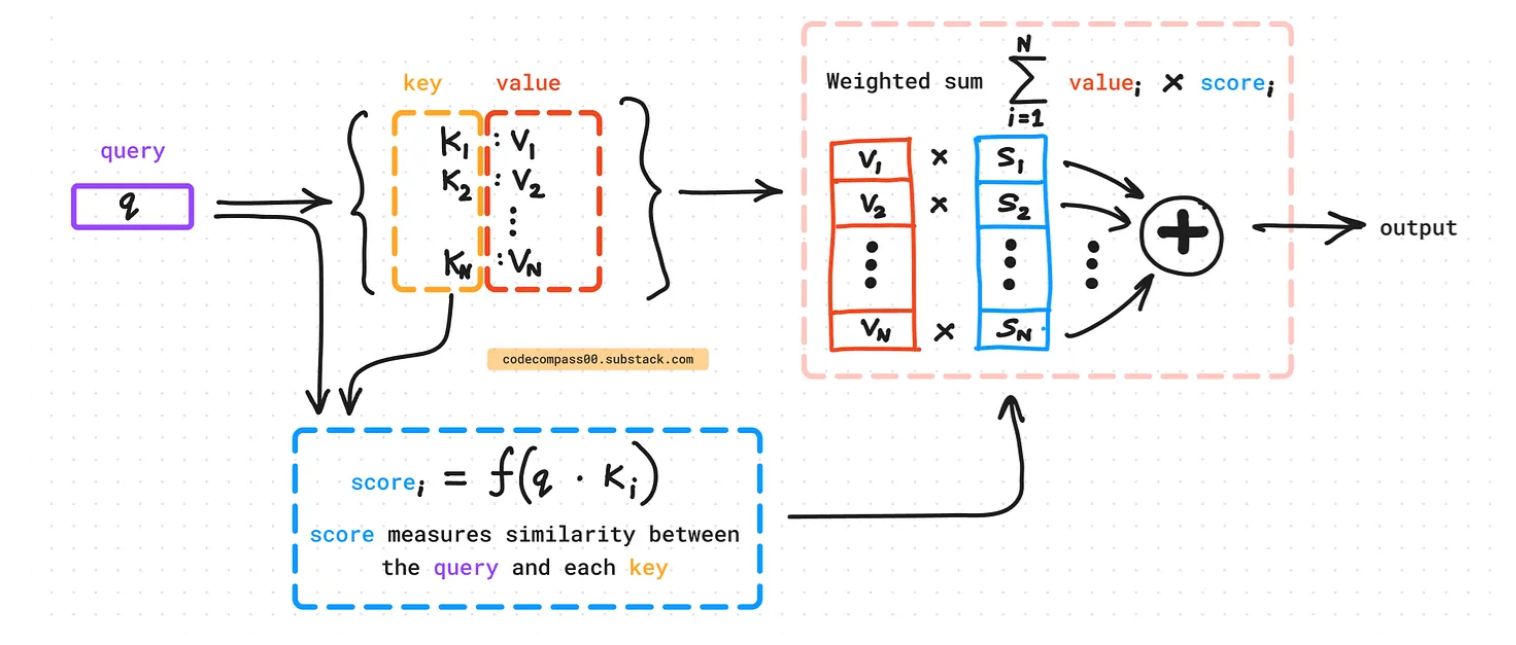

In [8]:
Image("attention1.png", width=1080)

### 예
 -  The animal didn't cross the street because it was too tired.
 -  The animal didn't cross the street because it was too wide.
 
  - Visualization tools
      - Transformer Explainer: https://poloclub.github.io/transformer-explainer/
      - Attention Visualizer : https://attention.streamlit.app/
  - 논문
      - "What Does BERT Look At?" (2019) Google Research 

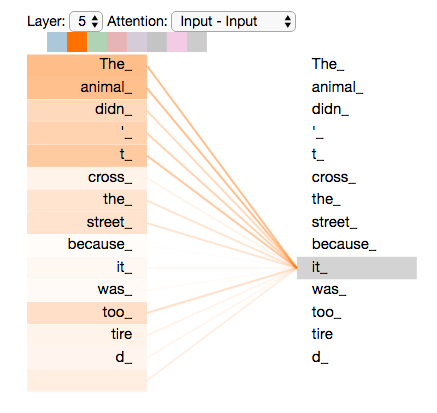

In [11]:
Image("attention2.png", width=480)

### 3) 세부 동작 예 

#### Encoder 

1. 입력
    - 단어 임베딩 (word embedding)
        - 단어 임베딩을 통해 단어를 $𝑑_{𝑚𝑜𝑑𝑒𝑙}$ 차원 벡터로 변환 (예: 512)
        - 𝑇개 단어로 구성된 문장을 한꺼번에 입력: $𝑇×𝑑_{𝑚𝑜𝑑𝑒𝑙}$ 크기의 $ 𝐒 $ 행렬
    - 단어의 순서 정보를 위한 위치 인코딩 (positional encoding)
        - 위치 정보를 표현한 $𝐏$를 $𝐒$에 더해 $𝐗$ 행렬 만들고 $𝐗$를 입력(세 행렬 모두 $𝑇×𝑑_{𝑚𝑜𝑑𝑒𝑙}$)
            $$ X = S + P $$
        - 예, $ p_{pos, 2i}   = sin( \frac{pos}{10000^{2i/d_{model}}})$,  $ p_{pos, 2i+1} = cos( \frac{pos}{10000^{2i/d_{model}}})$   

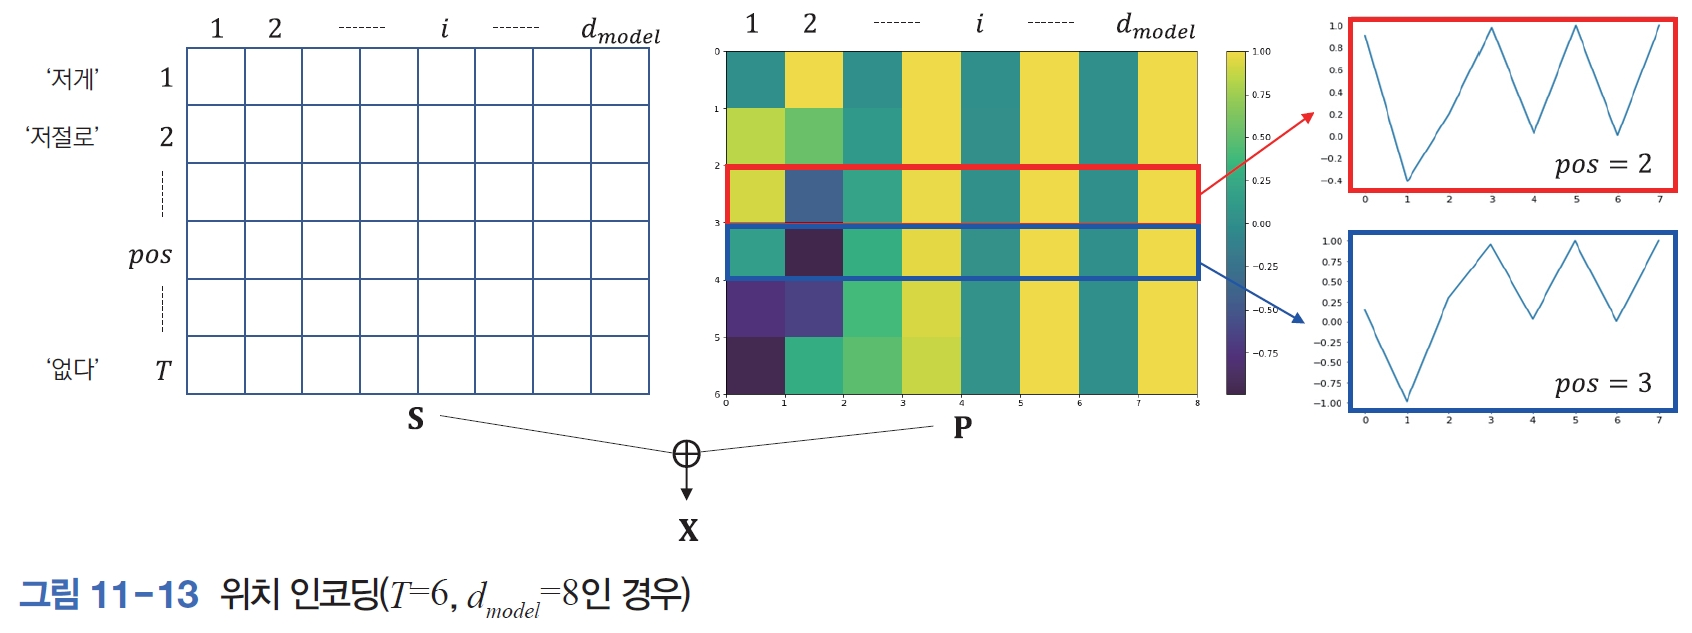

In [11]:
Image("그림 11-13.jpg", width=720)

3. Self-attention 
- 입력 행렬 $𝐗$에 대하여 가기 주목을 행함
- 여러개를 하기 때문에 MHA (Multi-Head Attention) 이라고 함: 다른 문법적이 요소에 집중한다고 생각하면 됨. 
- $X$에서 query, key, value 벡터를 생성 (학습 파라메터) 
    $$ Q = X W^{Q},  K = X W^{K},  V = X W^{V} $$

  여기서  $ W^{Q}$, $W^{K}$, $W^{V}$는 각각 $d_{query}$x$d_{model}$, $d_{key}$x$d_{model}$, $d_{value}$x$d_{model}$ 차원 (보통 $d_{key} = d_{query} = d_{value} = d_{model}/head$

- 각 헤더의 Attention계산 ($h = 1, \cdots H$)

    $$  C_h (X) = softmax (\frac{Q K^T}{\sqrt{d_{key}}} )  V  $$

- 멀티 해더 합산
    $$  C = MHA(X) =  concat (C_1, C_2, \cdots, C_H) W^{0} $$

- Resdual Add and NORM
   $$ X'  = Norm ( X  + C ) = Norm (X + MHA(X)) $$

3 위치 별 FF층position-wise Feed-Forward layer
  - 완전연결층은 벡터와 벡터를 연결하는데, 여기서는 $𝑇×𝑑_{𝑚𝑜𝑑𝑒𝑙}$ 크기의 행렬과 $𝑑_{𝑓𝑓}$ 차원의 벡터를 연결
  - $𝐗^′$의 행 각각을 벡터로 간주하여 $𝑑_{𝑚𝑜𝑑𝑒𝑙}$ 차원의 벡터와 $𝑑_{𝑓𝑓}$ 차원의 벡터를 연결하여 연산을 수행. 이런 연산을 $𝑇$개의 모든 행
  - 즉 모든 위치에 대해 독립적으로

    $$ X''  = FF(X') = Relu(X'W_1 + b_1)*W_2 + b_2  $$



**중요** 책의 예를 통하여 정확히 계산을 확인

#### Decoder

- 기본적인 동작원리를 Enocer 와 유사, 단 Cross-attention 가 masking 방식이 달라짐.

- 디코더 Masked MHA층
    - 아직 생성이 안된  행렬 일부를 마스크로 가리는 것을 뺌:  $𝐐𝐊^T$ 행렬의 대각선 위쪽에 있는 모든 요소를 아주 큰 음수로 설정
    - 교사 강요와 자기 회귀 방식
        - 학습 단계의 교사 강요:  Decoder가 정답이 아닌 답을 출력하더라도 정답으로 대치하고 다음단어 예측  
        - 추론 단계의 자기 회귀 방식: 추론시네응 정답이 없으므로 디코더가 출력한 결과를 그대로 사용
- Cross-Attention
    - query는 𝐗_dec를 사용하고 key와 value는 𝐗_enc를 사용
    - 번역에서는 출력 문장의 정보를 가진 query가 입력 문장의 정보를 가진 key와 value에 주목하는 정도를 계산하는 효과


## 4. Vision Transformer 

- Transformer의 어텐션 기법을 사용하여 영상 전체의 연관성을 결합하는 특징
- 언어모델과 통합이 유리 (multimodal)
- 현재는 성능이 CNN을 앞서고 있음 
   
- 대표 모델들 
   - ViT (2021): 분류 모델 
   - DETR (2020): 검출
   - SETR (2021): 문할 
   - MOTR, Trackformer (2021): 추적 
   - Swin Transfomer (2021): 분류, 검출, 분할, 추적을 모두 지원
   

### 1) ViT (Vision Transformer)

- 입력/출력 구조

   - 언어 transformer는 text 입출력으로, 입출력이 모두 1차원 임베딩 시퀀스
   - 영상은 2차원 구조: 입력을 patch로 잘라 1차원적으로 정렬, 위치정보를 넣기 위하여 position 정보를 더해 줌. 
   - 분류 문제의 출력은 하나의 값 (scalar 또는 크기 1의 벡터) : Transformer의 encoder만 사용  

- 처리 과정
   1. 이미지를 pxp 개의 겹치지 않는 패치로 나눔:  하나의 패치의 크기는 $(h/p, w/p, 3)$
   2. 하나의 패치를 1차원 또는 2차원적으로 embedding 하여 1차원 벡터로 변환 (CNN encoder 사용, 벡터의 크기 d_model)
   3. 맨 마지막에 CLS분류용 토큰을 하나 추가. 
       - Transformer의 encoder는 기본적으로 n개의 입력이 들어가면 n개의 출력이 나오는 구조
       - 최종 분류 출력용으로 하나의 공간을 추가로 만드는 방법.
   4. 여기에 패치의 위치정보를 나타내는 벡터정보를 포함한다.
   5. Transformer의 encoder를 통과
   6. 마지막 단의 CLS 토큰의 출력 결과를 classifier 로 사용한다.
   

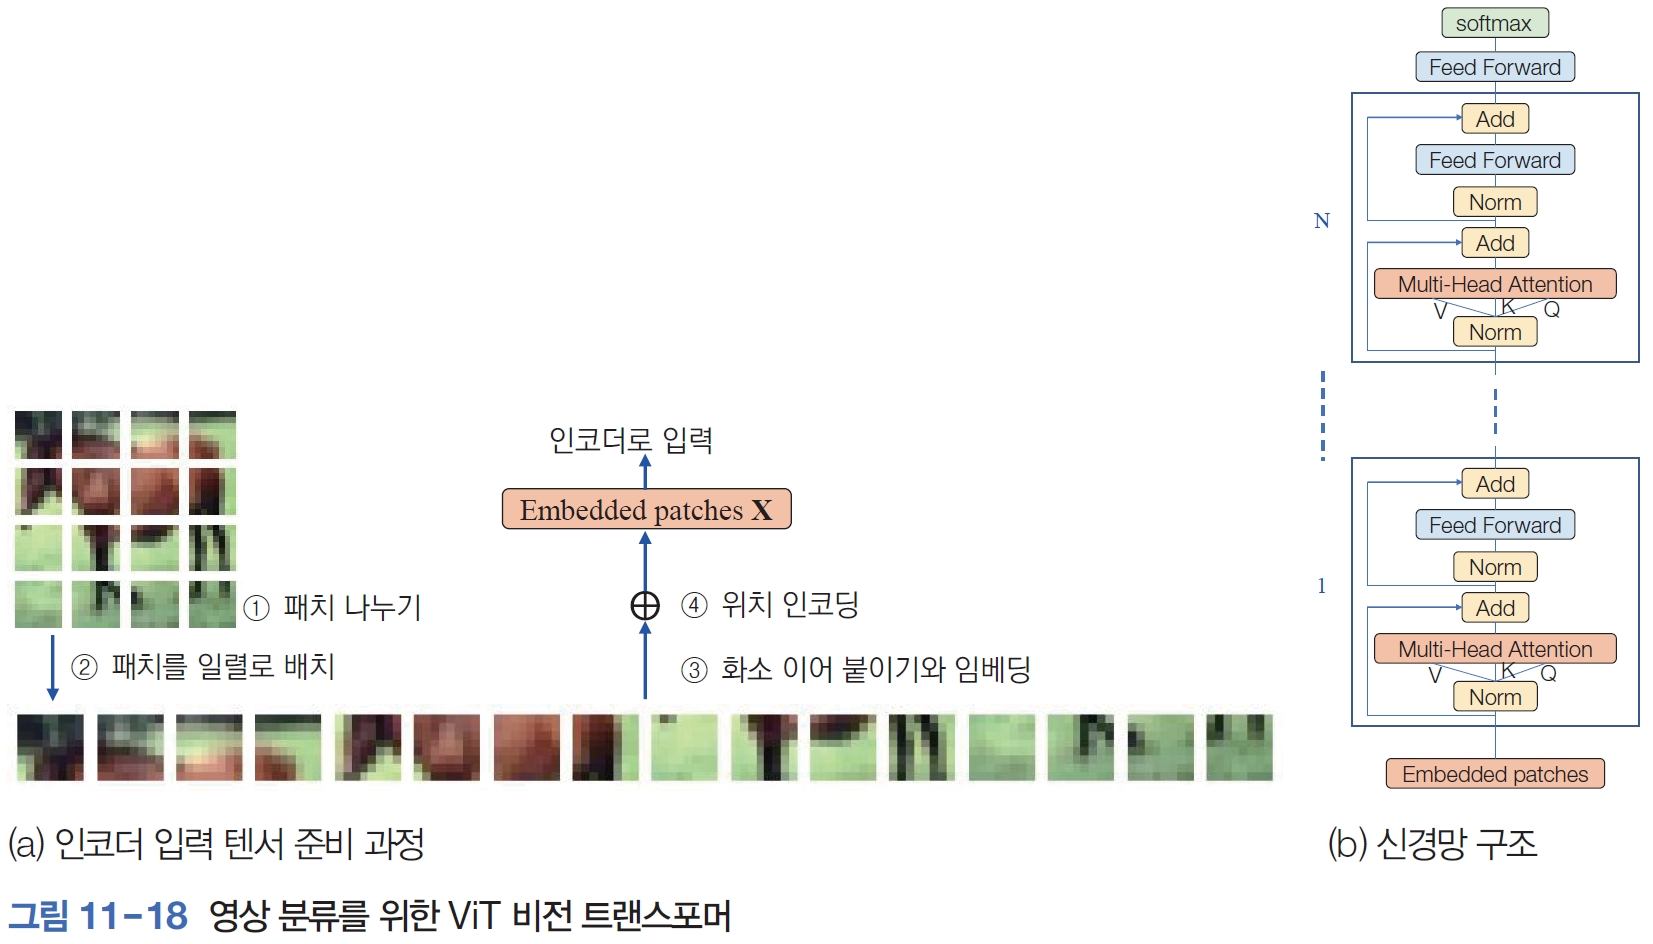

In [16]:
Image("그림 11-18.jpg", width=720)

## 멀티 모달 

- 멀티 모달은 정보의 포맷을 의미
    - 강아지라고 하면, 이를 사진 형태로 표시할 수도 있고,  강아지라는 문자로 표사할 수도, "강아지"라는 음성으로 표현도 가능함.
    - 하지만 결국 같은 것을 가르치는 것이고 머리속에는 같은 것으로 매핑되어 짐.

- 이들 다른 포맷들간의 연결성을 찾으면 자연스럽게 다른 모달 사이에 정보교류가 가능함.

### CLIP(Contrastive Language-Image Pre-training)

- 용도 
    - OpenAI가 2021년에 발표한 모델로, 이미지와 텍스트를 같은 벡터 공간에 매핑하여 서로 비교할 수 있도록 학습된 멀티모달(Multimodal) AI
    - 대조 학습 (Contrastive Learning): 올바른 이미지-텍스트쌍은 가까워지도록(Similarity 최대화), 잘못된 쌍은 멀어지도록(Similarity 최소화) 행렬 연산을 통해 동시에 학습.
    - 인터넷 규모의 데이터: 웹에서 수집한 4억 개(400M)의 이미지-텍스트 쌍(Image-Text Pairs)을 사전 학습(Pre-training)에 활용.

- 모델 구조 (Two-Tower Architecture)

    - Image Encoder: 이미지를 입력받아 특징 벡터(Embedding)로 변환 (Vision Transformer(ViT)나 ResNet 사용)
    - Text Encoder: 이미지에 대응하는 설명(Caption)을 입력받아 특징 벡터로 변환. (Transformer 기반 구조)
    - 공통 임베딩 공간 (Joint Embedding Space): 두 엔코더에서 나온 서로 다른 차원의 벡터를 동일한 차원으로 투영(Projection)
        - 이미지 코사인 유사도($\cos\theta$)를 직접 계산할 수 있음
          

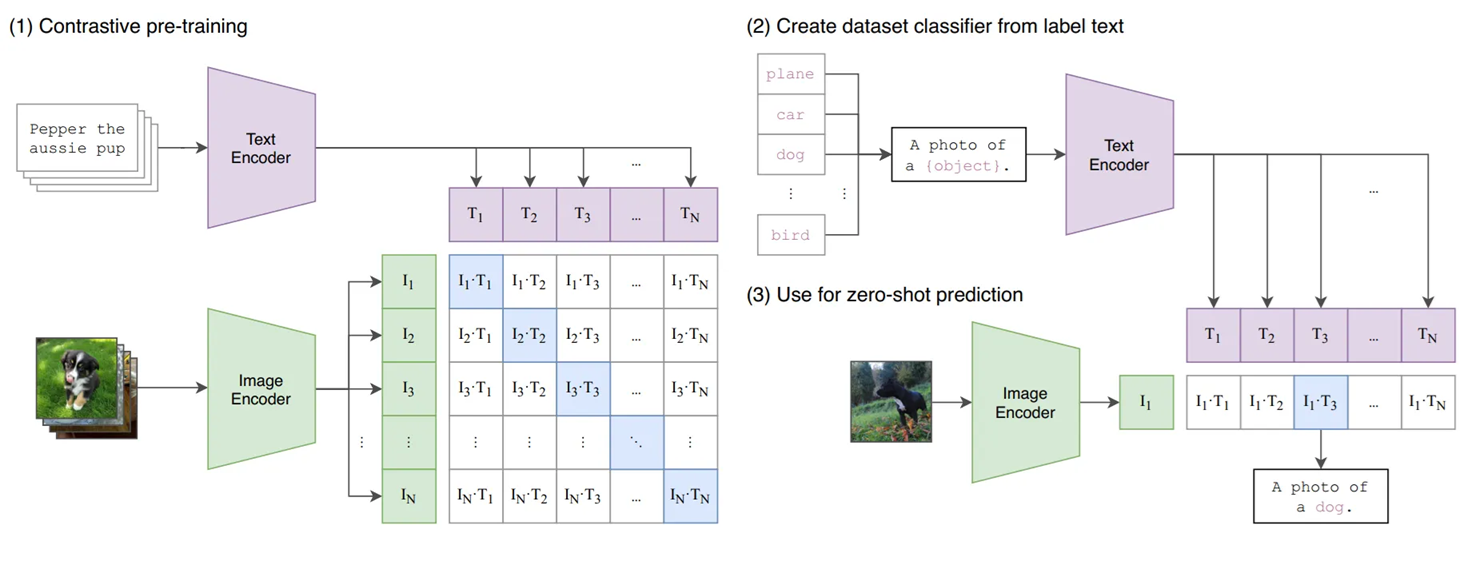

In [19]:
Image("clip.png", width=1024)

### 끝 